# **Competing Bandits in Matching Markets: Reproduction and Extensions**

*Flaminia Trinca (flaminia.trinca@students.unibe.ch) and*  
*Allizha Theiventhiram (allizha.theiventhiram@unine.ch)*

<br>

In this notebook, we reproduce and extend the results of the paper **_Competing Bandits in Matching Markets_** (Liu, Simchi-Levi, Wang, 2020).

The paper studies how Multi-Armed Bandit (MAB) algorithms behave when agents compete for arms, and allocations are determined by the **Gale–Shapley stable matching mechanism**.

Our notebook follows this structure:

<br>

### **Part 1 — Foundations**
We begin by re-implementing the core building blocks used throughout the paper:

1. **Multi-Armed Bandit algorithms** ([Github Code](https://github.com/guptav96/bandit-algorithms))
   - **ETC (Explore–Then–Commit)**  
   - **UCB (Upper Confidence Bound)**  
   with standard single-agent best-arm regret.

2. **Stable Matching** ([Github Code](https://github.com/lwcarani/matching-algorithms/tree/main))
   - **Gale–Shapley Deferred Acceptance Algorithm**,  
     in the agent-proposing version.

These implementations serve as warm-up components and do not interact yet.


### **Part 2 — Centralized Algorithms from the Paper**
We then implement the **centralized ETC and UCB mechanisms** described in the paper, where a platform:

- collects agents’ rankings of arms,
- uses **Gale–Shapley** to match agents to arms,
- and generates rewards based on agent–arm interactions.

We also implement the regret notions introduced in the paper:
- **Agent-optimal stable regret**,  
- **Agent-pessimal stable regret**,  
- and (for special examples) the simplified *slot-arm* baseline.

#### **Experiments from the paper**
We reproduce the main experimental results:

- **Example 2 (Figure 1a):**  
  Effect of the reward gap Δ in a 2×2 market under centralized UCB.

- **Example 6 (Figure 1b):**  
  Centralized UCB may suffer **linear agent-optimal stable regret**.

- **Example 7 (Figure 1c):**  
  Large market with global preferences; agents behave very differently depending on their rank.

These experiments validate the theoretical results of the paper.


### **Part 3 — Extended Analysis (Seminar Extensions)**

This final part implements the seminar extensions provided by the teaching assistant.  
Here we explore new behaviors not covered in the original paper.

#### **Extension A — Optimal-Matching Regret**
We introduce a purely structural notion of regret:
  
  $$
  R_{\mathrm{opt}}(T)
  = \sum_{t=1}^T \mathbf{1}\{ m_t \ne m^* \},
  $$
  
which counts how often the algorithm outputs a matching different from the **optimal stable matching**.  
Applied to Example 2, it clearly distinguishes ETC from UCB.


#### **Extension B — Random Two-Sided Markets**
We implement a **random instance generator** that produces arbitrary two-sided markets:

- random agent preferences,  
- random arm preferences,  
- consistent reward matrices on both sides.

We then evaluate:
- **UCB best-arm regret**,  
- **UCB pessimal-stable regret**,  
- **ETC best-arm regret**,  
- and compare their behavior across many independent random markets.

These experiments reveal strong instability and large performance variability in unstructured environments.


#### **Extension C — Two-Sided ETC**
We generalize the ETC algorithm so that **both agents and arms learn their preferences** during exploration.

We implement:
- a two-sided theoretical exploration horizon,  
- two-sided exploration and commit phases,  
- comparisons between:
  - **Two-Sided ETC vs One-Sided ETC**,  
  - **Two-Sided ETC vs centralized UCB**,  
  - and the effect of different exploration lengths $h$.

These experiments illustrate the severe fragility of explore–then–commit in two-sided learning environments.

<br>

### **Summary**
Across Parts 1–3, this notebook:

- reconstructs the theoretical mechanisms from **Competing Bandits in Matching Markets**,  
- reproduces the main experimental results from the paper,  
- and extends the analysis to **optimal-matching regret**, **random markets**, and **two-sided learning**.

Together, these experiments offer a comprehensive understanding of how bandit learning interacts with stable matching dynamics, and highlight both the strengths and limitations of centralized ETC and UCB in competitive environments.

<br>

---

In [46]:
!pip install matplotlib --quiet

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict
from typing import Dict, Set, Tuple, List, Optional

---
# **Part 1: Basic Implementations**
---

## **1.1. Multi-Armed Bandit Problem**


### **1.1.1 ETC: Explore-Then-Commit**

**Idea: two-phase strategy**

1. **Exploration phase:** Pull each arm a fixed number of times to estimate its expected reward.  
2. **Exploitation phase:** After exploration, select the arm with the highest estimated mean reward and play it for all remaining rounds.

**Pros**
- Simple and easy to analyze  
- Works well when the time horizon $T$ is known in advance  

**Cons**
- Once committed, the algorithm cannot recover from poor early estimates  
- Performance is sensitive to how much exploration is done


### **1.1.2 UCB: Upper Confidence Bound**

**Idea: dynamic exploration–exploitation trade-off**

At each time step, choose the arm with the highest **upper confidence bound** on its estimated mean reward.

A common choice is:

$$
a_t = \arg\max_i \left( \hat{\mu}_i(t) + \sqrt{\frac{2 \ln t}{n_i(t)}} \right),
$$

where

- $\hat{\mu}_i(t)$ is the empirical mean reward of arm $i$ up to time $t$
- $n_i(t)$ is the number of times arm $i$ has been pulled up to time $t$  
- $t$ is the current time step

**Intuition**

- The term $\hat{\mu}_i(t)$ encourages **exploitation** (play arms that have performed well so far).  
- The term $\sqrt{\frac{2 \ln t}{n_i(t)}}$ encourages **exploration** (try arms that have been played less often).  
- As $n_i(t)$ increases, the uncertainty term shrinks, so the algorithm gradually focuses on the best arms.

**Pros**
- Strong theoretical guarantees (logarithmic regret in $T$ under standard assumptions)  
- Automatically balances exploration and exploitation  

**Cons**
- Slightly more complex to implement and tune than ETC  

### **Implementation**

In [15]:
def ETC(arm_means, num_arms, total_steps, m):
    """
    Explore-Then-Commit for Bernoulli bandits.
    Exploration: pull each arm m times.
    Exploitation: pull best empirical arm.
    Returns regret matrix of shape (total_steps, num_iterations).
    """

    optimal_arm = np.argmax(arm_means)
    num_iterations = 10
    regret = np.zeros((total_steps, num_iterations))

    for it in range(num_iterations):
        num_steps = 0
        emp_means = np.zeros(num_arms)
        num_pulls = np.zeros(num_arms)

        # Exploration
        for _ in range(m):
            for j in range(num_arms):
                num_pulls[j] += 1
                reward = np.random.binomial(1, arm_means[j])
                emp_means[j] += (reward - emp_means[j]) / num_pulls[j]
                regret[num_steps, it] = arm_means[optimal_arm] - arm_means[j]
                num_steps += 1

        # Exploitation
        best_arm = np.argmax(emp_means)
        for _ in range(total_steps - m * num_arms):
            regret[num_steps, it] = arm_means[optimal_arm] - arm_means[best_arm]
            num_steps += 1

    return regret

In [16]:
def UCB(arm_means, num_arms, total_steps, delta=1e-4):
    """
    UCB1-style algorithm for Bernoulli bandits.
    Selects arm maximizing empirical_mean + sqrt(2 log(1/delta) / pulls).
    Returns regret matrix of shape (total_steps, num_iterations).
    """

    optimal_arm = np.argmax(arm_means)
    num_iterations = 10
    regret = np.zeros((total_steps, num_iterations))

    for it in range(num_iterations):
        emp_means = np.zeros(num_arms)
        num_pulls = np.zeros(num_arms)
        ucb = 100 * np.ones(num_arms)  # optimistic initialization

        for t in range(total_steps):
            arm = np.argmax(ucb)
            reward = np.random.binomial(1, arm_means[arm])
            num_pulls[arm] += 1

            regret[t, it] = arm_means[optimal_arm] - arm_means[arm]
            emp_means[arm] += (reward - emp_means[arm]) / num_pulls[arm]
            ucb[arm] = emp_means[arm] + np.sqrt(2 * np.log(1 / delta) / num_pulls[arm])

    return regret

### **Example Usage**

In [17]:
# Example problems
problems = [
    [0.01, 0.2, 0.8],
    [0.1, 0.5, 0.7],
    [0.4, 0.5, 0.55],
    [0.45, 0.46, 0.47]
]

total_steps = 1000
m = 100
etc_results, ucb_results = [], []

# Run ETC + UCB
for arm_means in problems:
    num_arms = len(arm_means)
    etc_reg = ETC(arm_means, num_arms, total_steps, m)
    ucb_reg = UCB(arm_means, num_arms, total_steps)

    etc_results.append(np.cumsum(np.mean(etc_reg, axis=1)))
    ucb_results.append(np.cumsum(np.mean(ucb_reg, axis=1)))

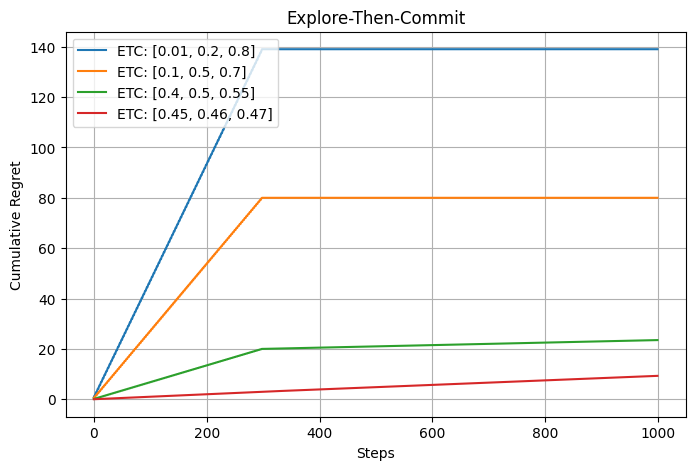

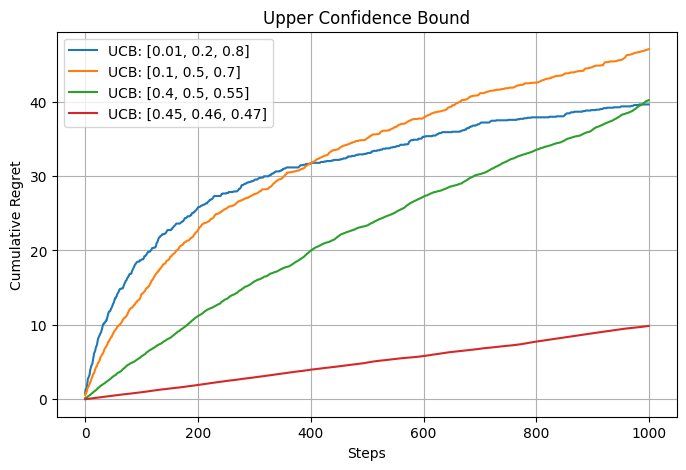

In [18]:
# Plot ETC
plt.figure(figsize=(8, 5))
for res, arm_means in zip(etc_results, problems):
    plt.plot(res, label=f"ETC: {arm_means}")
plt.xlabel("Steps")
plt.ylabel("Cumulative Regret")
plt.title("Explore-Then-Commit")
plt.legend()
plt.grid(True)
plt.show()

# Plot UCB
plt.figure(figsize=(8, 5))
for res, arm_means in zip(ucb_results, problems):
    plt.plot(res, label=f"UCB: {arm_means}")
plt.xlabel("Steps")
plt.ylabel("Cumulative Regret")
plt.title("Upper Confidence Bound")
plt.legend()
plt.grid(True)
plt.show()

---

## **1.2. Stable Matching Problem**


### **1.2.1 Gale–Shapley Algorithm**

**Goal**

Given two sets of equal size (e.g., employees and jobs), each with a strict preference ordering over the members of the other set, we want to find a **stable matching**: a pairing where there is no **blocking pair** (two agents who would both prefer each other to their current partners).

The Gale–Shapley algorithm guarantees:

- A **stable** outcome (no blocking pairs)  
- **Optimality for the proposing side** (e.g., employees)  
- **Pessimality for the other side** (e.g., jobs), among all stable matchings  

**Conceptual description of the algorithm (employees propose)**

1. **Initialization**  
   All employees and jobs are initially unmatched.

2. **Proposals**  
   Each unmatched employee proposes to the most preferred job on their list to which they have not yet proposed.

3. **Tentative acceptance**  
   Each job considers all proposals it has received (including any current tentative match) and:
   - keeps the most preferred employee as a **tentative match**,  
   - rejects all other proposers.

4. **Rejections**  
   Rejected employees remove that job from their preference list and will propose to their next preferred job in a future step.

5. **Repeat**  
   Steps 2–4 are repeated until no unmatched employee has any job left to propose to.

6. **Finalization**  
   All tentative matches at termination form the final (stable) matching.

### **Implementation**

In [19]:
def employee_without_match(matches: Dict[str, str], employees: Set[str]) -> str:
    """Return first unmatched employee, or None."""
    for e in employees:
        if e not in matches:
            return e
    return None


def gale_shapley(employee_prefs: Dict[str, List[str]],
                 job_prefs: Dict[str, List[str]]) -> Dict[str, str]:
    """
    Employee-proposing Gale–Shapley algorithm.
    Returns employee -> job matching.
    """

    unmatched = list(employee_prefs.keys())
    proposals = defaultdict(int)
    job_matches = {}  # job -> employee

    while unmatched:
        e = unmatched.pop(0)
        prefs = employee_prefs[e]
        j = prefs[proposals[e]]
        proposals[e] += 1

        if j not in job_matches:
            job_matches[j] = e
        else:
            current = job_matches[j]
            # prefer new proposer?
            if job_prefs[j].index(e) < job_prefs[j].index(current):
                job_matches[j] = e
                unmatched.append(current)
            else:
                unmatched.append(e)

    # invert mapping: employee -> job
    return {e: j for j, e in job_matches.items()}

#### **Example Usage**

In [20]:
# Random Example
employee_prefs = {
    "Alice": ["Google", "Amazon", "Meta"],
    "Bob": ["Amazon", "Google", "Meta"],
    "Carol": ["Amazon", "Meta", "Google"]
}

job_prefs = {
    "Google": ["Alice", "Bob", "Carol"],
    "Amazon": ["Bob", "Carol", "Alice"],
    "Meta": ["Carol", "Bob", "Alice"]
}

print(f"Agent-Optimal Stable Matching: {gale_shapley(employee_prefs, job_prefs)}")
print(f"Arm-Optimal Stable Matching:   {gale_shapley(job_prefs, employee_prefs)}")

Agent-Optimal Stable Matching: {'Alice': 'Google', 'Bob': 'Amazon', 'Carol': 'Meta'}
Arm-Optimal Stable Matching:   {'Google': 'Alice', 'Amazon': 'Bob', 'Meta': 'Carol'}


In [21]:
# Example from paper
arm_prefs = {
    "a1": ["p2","p3","p1"],
    "a2": ["p1","p2","p3"],
    "a3": ["p3","p1","p2"]
}

player_prefs = {
    "p1": ["a1","a2","a3"],
    "p2": ["a2","a1","a3"],
    "p3": ["a3","a1","a2"]
}

print(f"Agent-Optimal Stable Matching: {gale_shapley(player_prefs, arm_prefs)}")
print(f"Arm-Optimal Stable Matching:   {gale_shapley(arm_prefs, player_prefs)}")

Agent-Optimal Stable Matching: {'p1': 'a1', 'p2': 'a2', 'p3': 'a3'}
Arm-Optimal Stable Matching:   {'a1': 'p2', 'a2': 'p1', 'a3': 'p3'}


---
# **Part 2: Competing Bandits in Matching Markets**
---

## **2.1. Centralized Algorithms**

### **2.1.1 Setting**

We consider a matching market with

- **N** agents:   $P = \{\, p_1,\, p_2,\, \ldots,\, p_N \,\}$  
- **K** arms:     $K = \{\, a_1,\, a_2,\, \ldots,\, a_K \,\},$

with $N ≤ K$.

At each round *t*, every agent $p_i$ selects an arm $m_t(i)$, where  
$$ m_t \in K^N. $$  

If agent $p_i$ is matched to arm $m_t(i)$, they receive a stochastic reward $X_{i,m_t(i)}(t)$.

Each agent then submits a **ranking of arms** to a centralized platform.  
Each arm $a_j$ has a fixed and known ranking $\pi_j$ over agents, where  

$$
\pi_j(i)
$$  

denotes the **rank of player** $p_i$ **in the preference ordering of arm** $a_j$.

If multiple agents prefer the same arm, the arm selects its favorite according to $\pi_j$; only that agent receives the reward.

Rewards are **Gaussian random variables with variance 1**, and their means are denoted by $\mu_i(j)$ — the expected reward of agent *i* on arm *j*.


### **2.1.2 Centralized ETC (Explore–then–Commit Platform)**

**Exploration:**  
For the first **hK** rounds, the platform assigns agents to arms *cyclically* so that each agent samples every arm exactly **h** times (no conflicts).

**Commit:**  
After the exploration phase
1. Each agent ranks arms according to their empirical mean rewards $\hat{\mu}_{i,j}$,
2. The platform then computes a stable matching using the **agent-proposing Gale–Shapley algorithm**
3. The resulting stable matching is played for all remaining rounds.
*(This corresponds to Table 1, left, in the paper.)*


### **2.1.3 Centralized UCB (Gale–Shapley Platform)**

In the centralized UCB platform, the matching is recomputed **every round**. At every round *t*:

1. Each agent orders arms by their **Upper Confidence Bound (UCB)** scores:
   $$
   u_{i,j}(t) =
   \begin{cases}
   \infty, & \text{if } T_{i,j}(t) = 0, \\[6pt]
   \hat{\mu}_{i,j}(t) + \sqrt{\dfrac{3 \log t}{2\,T_{i,j}(t-1)}}, & \text{otherwise.}
   \end{cases}
   $$
   where $T_{i,j}(t)$ is the number of times $i$ has pulled arm $j$ up to time $t$

2. Each agent ranks arms using these UCB scores.

3. The centralized platform computes the **agent-optimal Gale–Shapley matching** for that round.

4. Only the **matched pairs’ statistics** $(i, j)$ are updated.  
*(See Table 1, right, and Equation (6) in the paper.)*


<br>
<br>

---

## **2.2. Regret Notions Used in This Notebook**

The paper analyzes two forms of regret:

### **2.2.1 Agent-Optimal Stable Regret (Paper Eq. (1), Example 6)**

**Definition:**  
$$
\overline{R}_i(t)
= t\,\mu_i(\overline{m}(i))
- \sum_{s=1}^t X_{i,m_s(i)}(s).
$$

**Where:**  
- `run_ucb_with_agent_optimal_regret` (used for Example 6)

**Purpose:**  
- This is the regret notion used to analyze **centralized ETC** in Theorem 1.  
- Also demonstrates that **UCB can fail** under optimal-stable regret (Example 6).

**Intuition:**  
- “How far am I from my *best stable partner*?”


### **2.2.2 Agent-Pessimal Stable Regret (Paper Eq. (2), Random Markets)**

**Definition:**  
$$
\underline{R}_i(t)
= t\,\mu_i(\underline{m}(i))
- \sum_{s=1}^t X_{i,m_s(i)}(s).
$$

**Where:**  
- `compute_pessimal_matching`  
- `run_random_experiment_full` (UCB in random markets)

**Purpose:**  
- This is the regret notion that **centralized UCB** is analyzed with in the paper (Theorem 5).

**Intuition:**  
- “Even compared to my *worst stable partner*, how well do I perform?”

<br>

In summary:  
- The **centralized ETC algorithm** is analyzed with respect to the **agent-optimal** stable regret.  
- The **centralized UCB algorithm** is analyzed with respect to the **agent-pessimal** stable regret.


<br>
<br>

---

## **2.3. Implementations**

Below we describe the main components of our implementation of centralized ETC and centralized UCB in matching markets.

### **2.3.1 Gale–Shapley (Agent-Proposing)**

We implement the classical deferred-acceptance algorithm, where **agents propose** and arms accept according to their fixed priorities.  
This produces the **agent-optimal** stable matching for any given agent rankings.

In [22]:
def gale_shapley_agent_proposing(rankings: List[np.ndarray], arm_pref: List[List[int]]) -> List[int]:
    """
    Agent-proposing Gale–Shapley.
    rankings[i]: arms best→worst for agent i.
    arm_pref[j]: agents best→worst for arm j.
    Returns matches[i] = arm index for agent i.
    """
    n_agents = len(rankings)
    n_arms = len(arm_pref)

    assigned = [-1] * n_arms
    proposals = [0] * n_agents
    matches = [-1] * n_agents
    free_agents = list(range(n_agents))

    while free_agents:
        i = free_agents.pop(0)
        if proposals[i] >= n_arms:
            continue
        arm = int(rankings[i][proposals[i]])
        proposals[i] += 1

        if assigned[arm] == -1:
            assigned[arm] = i
            matches[i] = arm
        else:
            current = assigned[arm]
            # arm chooses higher-priority agent
            if arm_pref[arm].index(i) < arm_pref[arm].index(current):
                assigned[arm] = i
                matches[i] = arm
                free_agents.append(current)
            else:
                free_agents.append(i)

    return matches

### **2.3.2 Theoretical Exploration Horizon $h$ for Centralized ETC**

According to Theorem 1 of the paper, $h$ should instead be set using a **theoretical formula** derived from concentration bounds.

For the agent-optimal stable regret guarantee in Theorem 1, the paper uses:

$$
h = \max\left\{1,\; \left\lceil \frac{4}{\Delta^{2}} \log\left(1 + \frac{n \Delta^{2} N}{4}\right) \right\rceil \right\}.
$$

where:
- $N$ is the number of agents,
- $n$ is the horizon (number of rounds),
- $\Delta$ is the **minimum reward gap** between the stable partner and any worse arm:

$$
\Delta = \min_{i, j : \mu_i(\bar m(i)) > \mu_i(j)} \big(\mu_i(\bar m(i)) - \mu_i(j)\big).
$$

To incorporate this into our implementation, we:
1. First compute the agent-optimal stable matching $\bar m$ under **true preferences** (using `compute_agent_optimal_matching`)
2. Compute the global minimum gap $\Delta$
3. Use the formula above to set $h$ if it is not provided by the user.

**Helper to compute Δ and theoretical h**:

In [23]:
def compute_agent_optimal_matching(mu: np.ndarray, arm_pref: List[List[int]]) -> Tuple[np.ndarray, List[np.ndarray]]:
    """
    Agent-optimal stable matching from true means mu.
    Returns m_opt[i] = arm for agent i and true rankings per agent.
    """
    n_agents, _ = mu.shape

    player_true_rankings = [np.argsort(-mu[i]) for i in range(n_agents)]
    m_opt_list = gale_shapley_agent_proposing(player_true_rankings, arm_pref)
    m_opt = np.array(m_opt_list, dtype=int)

    return m_opt, player_true_rankings


def compute_min_gap_and_h(mu: np.ndarray, arm_pref: List[List[int]], n_rounds: int) -> Tuple[float, int]:
    """
    Compute global gap Δ and theoretical h from Theorem 1:
    h = ceil( (4 / Δ^2) * log(1 + n Δ^2 N / 4) ).
    """
    m_opt, _ = compute_agent_optimal_matching(mu, arm_pref)
    m_opt = np.array(m_opt)

    n_agents, n_arms = mu.shape
    gaps = []

    for i in range(n_agents):
        best_arm = m_opt[i]
        best_mean = mu[i, best_arm]
        for j in range(n_arms):
            if mu[i, j] < best_mean:
                gaps.append(best_mean - mu[i, j])

    Delta = min(gaps)

    h_real = (4.0 / (Delta**2)) * np.log(1.0 + (n_rounds * (Delta**2) * n_agents) / 4.0)
    h = int(np.ceil(max(1.0, h_real)))

    return Delta, h

### **2.3.3 Centralized ETC**

The full ETC algorithm—exploration followed by a single Gale–Shapley commit phase—is implemented as:

In [24]:
def centralized_etc(mu: np.ndarray, arm_pref: List[List[int]], n_rounds: int = 400, h: Optional[int] = None, rng: Optional[np.random.Generator] = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Optional[List[np.ndarray]]]:
    """
    Centralized ETC with stable matching in commit phase.
    If h is None, use theoretical h from Theorem 1.
    Returns final_regret, regret_trace, matchings, rankings.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_agents, n_arms = mu.shape

    if h is None:
        Delta, h_theory = compute_min_gap_and_h(mu, arm_pref, n_rounds)
        h = h_theory
        print(f"[centralized_etc] Using theoretical h = {h} (Delta = {Delta:.4f})")

    rewards = np.zeros((n_agents, n_rounds))
    counts = np.zeros((n_agents, n_arms))
    means = np.zeros((n_agents, n_arms))

    matchings = np.full((n_rounds, n_agents), -1, dtype=int)
    optimal_means = np.array([mu[i, i if i < n_arms else n_arms - 1] for i in range(n_agents)])

    rankings = None
    t = 0

    # Exploration
    for _ in range(h):
        for shift in range(n_arms):
            if t >= n_rounds:
                break

            matches = [(i + shift) % n_arms for i in range(n_agents)]
            matchings[t] = matches

            for i in range(n_agents):
                arm = matches[i]
                r = rng.normal(mu[i, arm], 1.0)
                rewards[i, t] = r
                counts[i, arm] += 1
                means[i, arm] += (r - means[i, arm]) / counts[i, arm]

            t += 1
        if t >= n_rounds:
            break

    # Commit
    if t < n_rounds:
        rankings = [np.argsort(-means[i]) for i in range(n_agents)]
        matches_commit = gale_shapley_agent_proposing(rankings, arm_pref)

        while t < n_rounds:
            matchings[t] = matches_commit
            for i in range(n_agents):
                arm = matches_commit[i]
                r = rng.normal(mu[i, arm], 1.0)
                rewards[i, t] = r
                counts[i, arm] += 1
                means[i, arm] += (r - means[i, arm]) / counts[i, arm]
            t += 1

    # Regret
    t_axis = np.arange(1, n_rounds + 1)[None, :]
    regret_trace = t_axis * optimal_means[:, None] - np.cumsum(rewards, axis=1)
    final_regret = regret_trace[:, -1]

    return final_regret, regret_trace, matchings, rankings

### **2.3.4 Centralized UCB**

At each round, agents rank arms using UCB scores, and Gale–Shapley determines the matching.
Statistics are updated only for matched pairs.

In [25]:
def centralized_ucb(mu: np.ndarray, arm_pref: List[List[int]], n_rounds: int = 400, rng: Optional[np.random.Generator] = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Centralized UCB with GS matching each round.
    Returns final_regret, regret_trace, matchings, rewards.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_agents, n_arms = mu.shape
    rewards = np.zeros((n_agents, n_rounds))
    counts = np.zeros((n_agents, n_arms))
    means = np.zeros((n_agents, n_arms))

    matchings = np.full((n_rounds, n_agents), -1, dtype=int)
    optimal_means = np.array([mu[i, i if i < n_arms else n_arms - 1] for i in range(n_agents)])

    for t in range(1, n_rounds + 1):
        # 1) UCB scores
        ucb = np.zeros((n_agents, n_arms))
        for i in range(n_agents):
            for j in range(n_arms):
                if counts[i, j] == 0:
                    ucb[i, j] = np.inf
                else:
                    ucb[i, j] = means[i, j] + np.sqrt(3 * np.log(t) / (2 * counts[i, j]))

        # 2) Agent rankings
        rankings = [np.argsort(-ucb[i]) for i in range(n_agents)]

        # 3) Matching
        matches = gale_shapley_agent_proposing(rankings, arm_pref)
        matchings[t - 1] = matches

        # 4) Play matched arms
        for i in range(n_agents):
            arm = matches[i]
            r = rng.normal(mu[i, arm], 1.0)
            rewards[i, t - 1] = r
            counts[i, arm] += 1
            means[i, arm] += (r - means[i, arm]) / counts[i, arm]

    t_axis = np.arange(1, n_rounds + 1)[None, :]
    regret_trace = t_axis * optimal_means[:, None] - np.cumsum(rewards, axis=1)
    final_regret = regret_trace[:, -1]

    return final_regret, regret_trace, matchings, rewards

In [26]:
def run_trials_centralized_ucb(mu: np.ndarray, arm_pref: List[List[int]], n_rounds: int, n_trials: int, seed: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Average final and cumulative regrets across trials for centralized UCB.
    """
    rng = np.random.default_rng(seed)
    n_agents = mu.shape[0]

    finals = np.zeros((n_trials, n_agents))
    cum = np.zeros((n_trials, n_agents, n_rounds))

    for k in range(n_trials):
        r_final, r_trace, _, _ = centralized_ucb(mu, arm_pref, n_rounds=n_rounds, rng=rng)
        finals[k] = r_final
        cum[k] = r_trace

    return finals.mean(axis=0), cum.mean(axis=0)

### **2.3.5 Agent-Optimal Stable Regret for Centralized UCB**

Although centralized UCB is analyzed in the paper using agent-pessimal regret, some experiments (e.g., Example 6) require computing agent-optimal regret.
We implement this using:

In [27]:
def run_ucb_with_agent_optimal_regret(mu: np.ndarray, arm_pref: List[List[int]], n_rounds: int, n_trials: int, seed: int = 0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Centralized UCB evaluated with agent-optimal stable regret.
    Returns time axis, average regret trace, and agent-optimal matching.
    """
    rng = np.random.default_rng(seed)
    n_agents, _ = mu.shape

    m_opt, _ = compute_agent_optimal_matching(mu, arm_pref)
    baseline_means = mu[np.arange(n_agents), m_opt]

    all_regrets = np.zeros((n_trials, n_agents, n_rounds))

    for trial in range(n_trials):
        _, _, _, rewards = centralized_ucb(mu, arm_pref, n_rounds=n_rounds, rng=rng)

        cum_rewards = np.cumsum(rewards, axis=1)
        t_axis = np.arange(1, n_rounds + 1)
        baseline_trace = baseline_means[:, None] * t_axis[None, :]
        regret_trace = baseline_trace - cum_rewards
        all_regrets[trial] = regret_trace

    avg_regret_trace = all_regrets.mean(axis=0)
    return t_axis, avg_regret_trace, m_opt

## **2.4. Experiments from the Paper**

In this section, we reproduce the main experimental results from the paper *Competing Bandits in Matching Markets*, namely **Examples 2, 6, and 7** (shown in Figures **1a**, **1b**, and **7** of the original text).

Each experiment simulates the interaction of a set of **agents** and **arms** under the **centralized UCB algorithm** (and in some cases also the centralized ETC algorithm).  
All rewards are sampled from **Gaussian distributions with variance 1**, as stated in the paper’s appendix.  
For each setup, we perform multiple independent trials and plot the agents’ **expected cumulative regret** averaged across trials.



### **2.4.1 Example 2 — Dependence on the Reward Gap (Figure 1a)**
This example studies how the **reward gap** $ \Delta $ affects the expected regret of each agent.

- There are **2 agents** ($p_1, p_2$) and **2 arms** ($a_1, a_2$).  
- Both arms prefer agent $p_1$ over $p_2$.  
- Agent $p_2$ receives Gaussian rewards with means $0$ and $1$ from arms $a_1$ and $a_2$, respectively.  
- Agent $p_1$’s rewards depend on the gap $ \Delta $: means $(\Delta, 0)$.  
- We vary $ \Delta \in [0,1] $, run the **centralized UCB** algorithm with horizon $n = 400$ and **100 trials**, and measure each agent’s total regret.

The result shows that a **smaller reward gap** makes it harder for $p_1$ to correctly identify their preferred arm, leading to **larger expected regret**.

Note: Example 2 uses standard regret (best-arm regret), not agent-optimal stable regret.
This matches the original paper (Figure 1a).

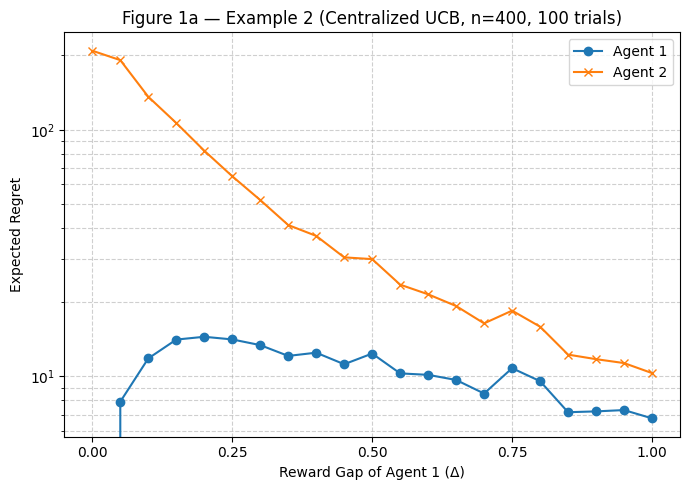

In [28]:
n_rounds = 400
n_trials = 100
deltas = np.linspace(0.0, 1.0, 21)
np.random.seed(0)

arm_pref_ex2 = [[0, 1], [0, 1]]

avg_r1, avg_r2 = [], []

for Delta in deltas:
    mu_ex2 = np.array([
        [Delta, 0.0],
        [0.0,  1.0],
    ], dtype=float)

    final_mean, _ = run_trials_centralized_ucb(
        mu_ex2, arm_pref_ex2, n_rounds=n_rounds,
        n_trials=n_trials, seed=0
    )
    avg_r1.append(final_mean[0])
    avg_r2.append(final_mean[1])

plt.figure(figsize=(7, 5))
plt.plot(deltas, avg_r1, 'o-', label='Agent 1')
plt.plot(deltas, avg_r2, 'x-', label='Agent 2')
plt.yscale('log')
plt.xticks(np.arange(0, 1.01, 0.25))
plt.xlabel('Reward Gap of Agent 1 (Δ)')
plt.ylabel('Expected Regret')
plt.title('Figure 1a — Example 2 (Centralized UCB, n=400, 100 trials)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### **2.4.2 Example 6 — Linear Agent-Optimal Regret (Figure 1b)**

This example demonstrates that the **centralized UCB** algorithm may fail to achieve sublinear agent-optimal regret under certain preference structures.

- There are **3 agents** ($p_1, p_2, p_3$) and **3 arms** ($a_1, a_2, a_3$).  
- Agents’ preferences:
  $$
  p_1: a_1 \succ a_2 \succ a_3, \quad
  p_2: a_2 \succ a_1 \succ a_3, \quad
  p_3: a_3 \succ a_1 \succ a_2
  $$
- Arms’ preferences:
  $$
  a_1: p_2 \succ p_3 \succ p_1, \quad
  a_2: p_1 \succ p_2 \succ p_3, \quad
  a_3: p_3 \succ p_1 \succ p_2
  $$
- Reward means (Gaussian, variance 1):
  - $p_1$: $[2, 1, 0]$
  - $p_2$: $[1, 2, 0]$
  - $p_3$: $[1, 0, 1.05]$

We run the **centralized UCB** algorithm for **200 rounds** and **100 trials**.

The result shows that while $p_3$’s regret remains small, the other agents suffer **approximately linear regret** over time, confirming the paper’s theoretical insight that centralized UCB can fail to converge to the agent-optimal stable match.

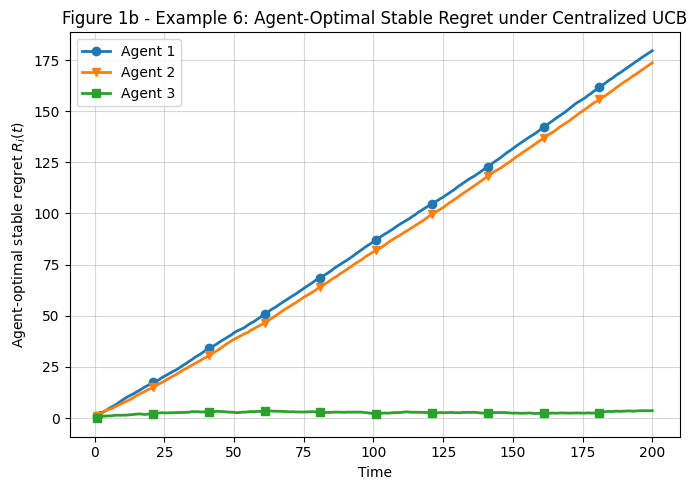

In [29]:
n_rounds_ex6 = 200
n_trials_ex6 = 100

arm_pref_ex6 = [
    [1, 2, 0],
    [0, 1, 2],
    [2, 0, 1],
]

mu_ex6 = np.array([
    [2.0, 1.0, 0.0],
    [1.0, 2.0, 0.0],
    [1.0, 0.0, 1.05],
], dtype=float)

t_ex6, avg_regret_ex6, m_opt_ex6 = run_ucb_with_agent_optimal_regret(mu_ex6, arm_pref_ex6, n_rounds=n_rounds_ex6, n_trials=n_trials_ex6, seed=11)

plt.figure(figsize=(7, 5))
plt.plot(t_ex6, avg_regret_ex6[0], marker='o', markevery=20, linewidth=2, label='Agent 1')
plt.plot(t_ex6, avg_regret_ex6[1], marker='v', markevery=20, linewidth=2, label='Agent 2')
plt.plot(t_ex6, avg_regret_ex6[2], marker='s', markevery=20, linewidth=2, label='Agent 3')

plt.xlabel("Time")
plt.ylabel("Agent-optimal stable regret $R_i(t)$")
plt.title("Figure 1b - Example 6: Agent-Optimal Stable Regret under Centralized UCB")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### **2.4.3 Example 7 — Global Preferences (Figure 7)**

This example examines the case where all agents and arms have **aligned global preferences**.

- There are **20 agents** and **20 arms**.  
- All agents rank the arms identically: $a_1 \succ a_2 \succ \dots \succ a_{20}$.  
- All arms rank the agents identically: $p_1 \succ p_2 \succ \dots \succ p_{20}$.  
- The unique stable matching is $(p_i, a_i)$ for all $i$.  
- The reward means decrease uniformly across arms with a gap of $0.1$ between consecutive arms.  
  For every agent $p_i$:  
  $$
  \mu_i = [2.0, 1.9, 1.8, \dots, 0.1]
  $$

We run **centralized UCB** with horizon $n = 8000$ and **50 trials**.

The results reproduce the paper’s findings:
- Top-ranked agents (e.g., $p_1$) achieve **sublinear regret**.
- Lower-ranked agents’ regret curves flatten or even become negative, consistent with the theoretical bounds in Equation (10).

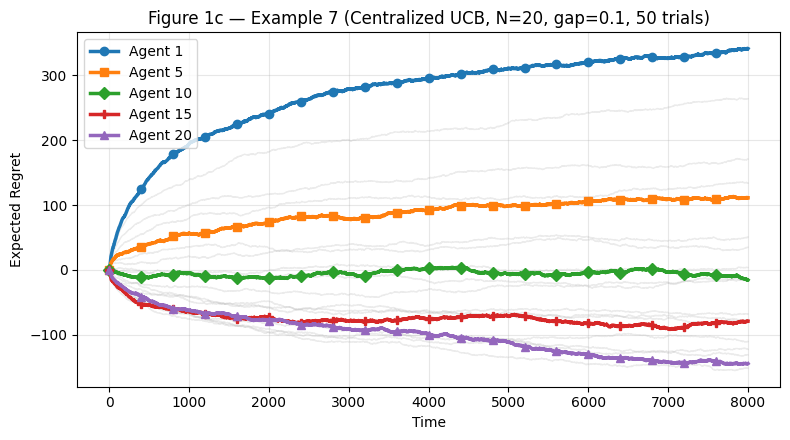

In [30]:
np.random.seed(23)

N = 20
n_rounds = 8000
n_trials = 50
gap = 0.1
base = 2.0

arm_pref_ex7 = [list(range(N)) for _ in range(N)]

mu_ex7 = np.zeros((N, N), dtype=float)
for i in range(N):
    for j in range(N):
        mu_ex7[i, j] = base - gap * j

final_mean_ex7, avg_cum_trace_ex7 = run_trials_centralized_ucb(mu_ex7, arm_pref_ex7, n_rounds=n_rounds, n_trials=n_trials, seed=23)

t = np.arange(1, n_rounds + 1)
plt.figure(figsize=(8, 4.5))

highlight = [0, 4, 9, 14, 19]
others = [i for i in range(N) if i not in highlight]

for i in others:
    plt.plot(t, avg_cum_trace_ex7[i], linewidth=1, alpha=0.25, color='0.7')

markers = ['o', 's', 'D', 'P', '^']
labels = ['Agent 1', 'Agent 5', 'Agent 10', 'Agent 15', 'Agent 20']
for k, i in enumerate(highlight):
    plt.plot(t, avg_cum_trace_ex7[i], linewidth=2.5, marker=markers[k], markevery=400, label=labels[k])

plt.xlabel('Time')
plt.ylabel('Expected Regret')
plt.title('Figure 1c — Example 7 (Centralized UCB, N=20, gap=0.1, 50 trials)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
# **Part 3: Extensions**
---

## **3.1 Extension A — Optimal-Matching Regret**

In the paper *Competing Bandits in Matching Markets*, all regret notions are **reward-based**:  
they compare the total reward collected by the algorithm to the reward under a fixed benchmark
stable matching (agent-optimal or agent-pessimal).  

However, these reward-based notions **do not directly measure** how well the algorithm
identifies the **correct stable matching** over time.  
Two algorithms may collect similar rewards, even if one consistently outputs the *wrong* matching.

##### **Goal of this extension:**

In this extension, we explore a more **combinatorial** performance measure that focuses solely on:

> **Does the algorithm produce the correct stable matching at round $t$ or not?**

This allows us to study the **stability-identification behavior** of centralized ETC and UCB,
separate from their reward performance.


### **3.1.1 Optimal-Matching Regret**

Let:

- $m_t$ be the matching produced by the algorithm at round $t$,
- $m^*$ be the **true agent-optimal stable matching** (computed using true preferences),
- $\mathbf{1}\{\cdot\}$ denote the indicator function.

We define the **optimal-matching regret** as:

$$
R_{\mathrm{opt}}(T)
=
\sum_{t=1}^{T} \mathbf{1}\{ m_t \neq m^* \}.
$$

In words:

- At each round, we check whether the algorithm outputs the **correct** stable matching.
- If not, we add 1 to the regret count.
- The value $R_{\mathrm{opt}}(T)$ tells us **how many rounds** the algorithm has *failed* to return the optimal stable matching.

This metric completely ignores reward magnitudes.  
It only cares about whether the **structure** of the matching is correct.



##### **Why this notion is interesting:**

- In reward-based regret, the algorithm could perform reasonably well even if it plays the wrong matching occasionally (or even frequently), as long as rewards are similar.
- In contrast, **optimal-matching regret** highlights *structural failures*:  
  it penalizes **every round in which the matching is wrong**, regardless of how large or small the reward gap is.

This is useful for understanding:

1. **How quickly an algorithm identifies the optimal matching**, and  
2. **Whether it maintains the correct matching over time**.

Since ETC **commits once** and UCB **keeps updating**, the two algorithms behave very differently under this metric.



### **3.1.2 What we do in this subsection:**

1. Implement a helper to compute $R_{\mathrm{opt}}(T)$ from a sequence of matchings.
2. Apply it to **Example 2** for:
   - Centralized UCB  
   - Centralized ETC
3. Compare how often each algorithm deviates from the optimal stable matching.

In [31]:
def optimal_matching_regret(matchings: np.ndarray, optimal_matching: np.ndarray) -> np.ndarray:
    """
    Optimal-matching regret R_opt(t): cumulative number of rounds with m_t ≠ m*.
    """
    diff = matchings != optimal_matching[None, :]
    indicator = np.any(diff, axis=1).astype(int)
    return np.cumsum(indicator)


def compute_Ropt_over_trials(alg_fn, mu: np.ndarray, player_true_rankings, arm_pref, n_rounds: int, n_trials: int, rng_seed: int = 0, **alg_kwargs):
    """
    Run a centralized algorithm multiple times and average R_opt(t).
    """
    rng = np.random.default_rng(rng_seed)
    N = mu.shape[0]
    T = n_rounds

    # Agent-optimal stable matching m*
    m_star = gale_shapley_agent_proposing(player_true_rankings, arm_pref)
    m_star = np.array(m_star, dtype=int)

    Ropt_all = np.zeros((n_trials, T))

    for k in range(n_trials):
        _, _, matchings, _ = alg_fn(mu, arm_pref, n_rounds=n_rounds, rng=rng,**alg_kwargs)
        Ropt_all[k] = optimal_matching_regret(matchings, m_star)

    Ropt_mean = Ropt_all.mean(axis=0)
    t = np.arange(1, T + 1)
    return t, Ropt_mean, m_star

**Example**

[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 63 (Delta = 0.5000)
[centralized_etc] Using theoretical h = 

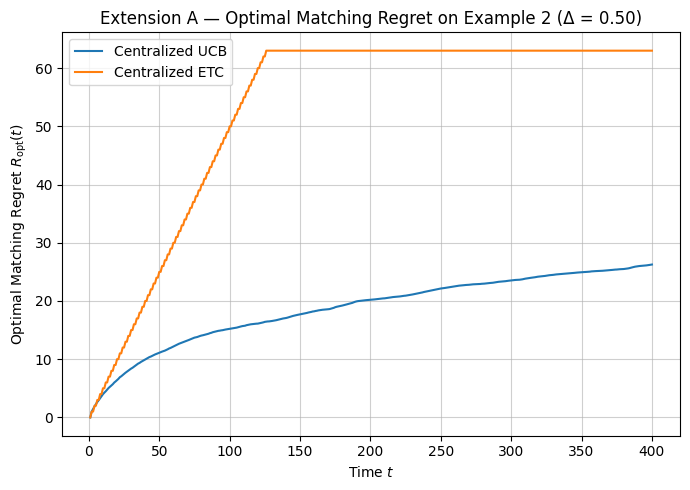

In [32]:
n_rounds = 400
n_trials = 100
Delta = 0.5

mu_ex2 = np.array([
    [Delta, 0.0],
    [0.0,  1.0],
], dtype=float)

arm_pref_ex2 = [[0, 1], [0, 1]]

true_rankings_ex2 = [
    np.array([0, 1], dtype=int),
    np.array([1, 0], dtype=int),
]

t, Ropt_ucb, m_star = compute_Ropt_over_trials(
    centralized_ucb,
    mu_ex2,
    true_rankings_ex2,
    arm_pref_ex2,
    n_rounds=n_rounds,
    n_trials=n_trials,
    rng_seed=42,
)

_, Ropt_etc, _ = compute_Ropt_over_trials(
    centralized_etc,
    mu_ex2,
    true_rankings_ex2,
    arm_pref_ex2,
    n_rounds=n_rounds,
    n_trials=n_trials,
    rng_seed=43
)

plt.figure(figsize=(7, 5))
plt.plot(t, Ropt_ucb, label='Centralized UCB')
plt.plot(t, Ropt_etc, label='Centralized ETC')
plt.xlabel('Time $t$')
plt.ylabel(r'Optimal Matching Regret $R_{\mathrm{opt}}(t)$')
plt.title(f'Extension A — Optimal Matching Regret on Example 2 (Δ = {Delta:.2f})')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### **3.1.3 Discussion**

##### **What we measured**

The optimal-matching regret  
$$
R_{\mathrm{opt}}(t) = \sum_{s=1}^{t} \mathbf{1}\{ m_s \neq m^* \}
$$  
counts **how many rounds** the algorithm outputs a matching that is **not equal** to the true optimal stable matching $m^*$.  

Unlike reward-based regret, this metric cares *only* about whether the **structure** of the matching is correct, regardless of how small or large the reward differences are.

##### **Behavior on Example 2 ($\Delta = 0.5$)**

The two algorithms behave very differently:

- **Centralized UCB**  
  $R_{\mathrm{opt}}(t)$ grows slowly and then plateaus.  
  After some initial exploration noise, UCB **recovers** and keeps producing the correct matching for most future rounds.

- **Centralized ETC**  
  $R_{\mathrm{opt}}(t)$ grows *almost linearly*.  
  Once ETC commits (based on potentially noisy early samples), it **sticks to its decision forever**, even if that decision was wrong.

##### **Why this difference occurs**

- **UCB continually updates** its estimates.  
  If it makes an early mistake, later observations can correct it.

- **ETC explores once** and commits permanently.  
  A single unlucky exploration phase can lock it into an incorrect matching for the entire horizon.

##### **Key takeaway**

Optimal-matching regret highlights a structural property that reward-based regret may miss:

- **UCB is adaptive**—it typically finds and maintains the optimal stable matching.  
- **ETC is brittle**—any early error leads to a persistent mismatch and linear regret.

This makes $R_{\mathrm{opt}}(t)$ a valuable diagnostic metric for understanding how reliably an algorithm identifies and preserves the correct stable matching.



## **3.2 Extension B — Random Instance Generator and Experiments in Two-Sided Markets**

In earlier sections, we analyzed **hand-crafted examples** from the paper (Examples 2, 6, and 7).  
These instances were deliberately structured to highlight specific theoretical phenomena:
- unique stable matchings,  
- clean preference orderings,  
- simple conflicts between agents and arms.

However, **real matching markets are rarely this structured**.  
Preferences are often complicated, rewards are noisy, and stable matchings may not be unique.

##### **Goal of this extension**

The goal of Extension B is to explore how centralized bandit algorithms behave in **general, unstructured matching markets** by:

1. **Generating fully random two-sided instances**, with:
   - random agent preferences over arms,
   - random arm preferences over agents,
   - mean rewards consistent with these rankings.

2. **Running centralized UCB and ETC on these markets.**

3. **Evaluating multiple regret notions** to understand:
   - learning performance,
   - stability behavior,
   - robustness to randomness,
   - sensitivity to preference conflicts.

This moves our analysis beyond the carefully designed examples in the paper, and toward
a more realistic assessment of bandit algorithms in matching markets.


### **3.2.1 B1 — Random Instance Generator**

We first implement a generator for arbitrary two-sided matching markets (agents + arms).  
Given:
- $N$ agents,
- $K$ arms,
- reward gap interval $[\Delta_{\min}, \Delta_{\max}]$,

the generator samples:

1. **Strict preference orders**
   - each agent receives a uniform random permutation of arms,
   - each arm receives a uniform random permutation of agents.

2. **Consistent mean rewards**
   - least-preferred option receives mean 0,
   - moving up the ranking adds a random gap in $[\Delta_{\min},\Delta_{\max}]$,
   - guarantees that reward means reflect preferences.

This yields a random but **internally consistent** two-sided instance.

In [33]:
def generate_random_instance(N: int, K: int, delta_min: float, delta_max: float, rng: Optional[np.random.Generator] = None):
    """
    Random two-sided instance: preferences and consistent mean rewards.
    Returns player_prefs, arm_prefs, mu_players (N×K), gamma_arms (K×N).
    """
    if rng is None:
        rng = np.random.default_rng()

    # Random strict preferences
    player_prefs = [rng.permutation(K).tolist() for _ in range(N)]
    arm_prefs = [rng.permutation(N).tolist() for _ in range(K)]

    # Agent-side means µ (consistent with player_prefs)
    mu_players = np.zeros((N, K))
    for i in range(N):
        ranking = player_prefs[i]        # best → worst
        mu_players[i, ranking[-1]] = 0.0
        for idx in range(K - 2, -1, -1):
            worse = ranking[idx + 1]
            better = ranking[idx]
            gap = rng.uniform(delta_min, delta_max)
            mu_players[i, better] = mu_players[i, worse] + gap

    # Arm-side means γ (consistent with arm_prefs)
    gamma_arms = np.zeros((K, N))
    for j in range(K):
        ranking = arm_prefs[j]           # best → worst
        gamma_arms[j, ranking[-1]] = 0.0
        for idx in range(N - 2, -1, -1):
            worse = ranking[idx + 1]
            better = ranking[idx]
            gap = rng.uniform(delta_min, delta_max)
            gamma_arms[j, better] = gamma_arms[j, worse] + gap

    return player_prefs, arm_prefs, mu_players, gamma_arms

In [34]:
def run_random_instance_experiment_two_sided(N: int = 6, K: int = 6, delta_min: float = 0.2, delta_max: float = 0.5, n_rounds: int = 500, n_trials: int = 20, seed: int = 0) -> np.ndarray:
    """
    Average best-arm regret for centralized UCB on random two-sided markets.
    """
    rng = np.random.default_rng(seed)
    cum_regret_all = []

    for _ in range(n_trials):
        prefs_players, prefs_arms, mu_players, gamma_arms = generate_random_instance(N, K, delta_min, delta_max, rng=rng)

        _, _, _, rewards = centralized_ucb(mu_players, prefs_arms, n_rounds=n_rounds, rng=rng)

        best_means = np.max(mu_players, axis=1)
        t_grid = np.arange(1, n_rounds + 1)
        optimal_reward = best_means[:, None] * t_grid[None, :]
        obtained_reward = np.cumsum(rewards, axis=1)
        regret = optimal_reward - obtained_reward

        cum_regret_all.append(regret)

    cum_regret_all = np.array(cum_regret_all)
    return cum_regret_all.mean(axis=0)

**Example**

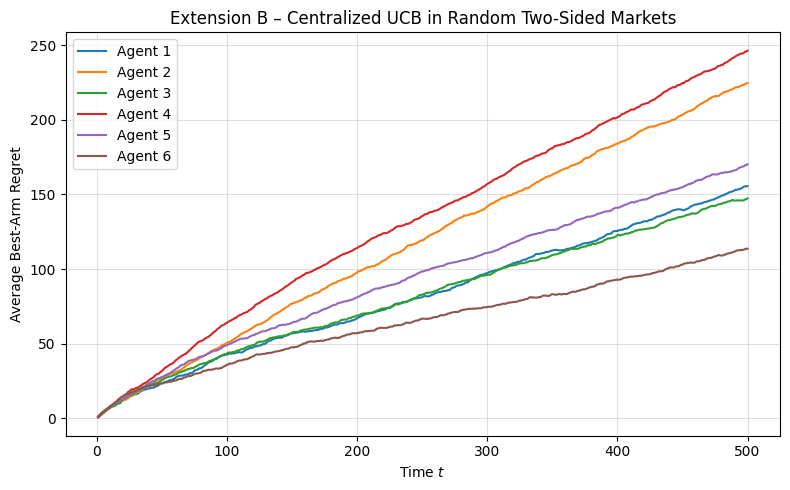

In [35]:
avg_regret_random = run_random_instance_experiment_two_sided(
    N=6, K=6,
    delta_min=0.2, delta_max=0.5,
    n_rounds=500,
    n_trials=20,
    seed=42
)

T = avg_regret_random.shape[1]
t_axis = np.arange(1, T + 1)

plt.figure(figsize=(8, 5))
for i in range(avg_regret_random.shape[0]):
    plt.plot(t_axis, avg_regret_random[i], label=f"Agent {i+1}")
plt.xlabel("Time $t$")
plt.ylabel("Average Best-Arm Regret")
plt.title("Extension B – Centralized UCB in Random Two-Sided Markets")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### **Discussion (B1)**

In this experiment we measured **best-arm regret** under centralized UCB across many randomly generated two-sided markets.  
Each trial used independently sampled preferences and consistent mean rewards for both sides.

##### **What we observed**
- Regret generally grows **linearly** for most agents.  
- There is **large variability** across agents:  
  some consistently receive favorable assignments, while others lose repeated conflicts and accumulate large regret.  
- These differences arise entirely from **random asymmetries** in preferences and arm priorities.

##### **Why this matters**
- Unlike the clean examples from the paper, random markets contain many conflicting preference cycles and unstable interactions.  
- Centralized UCB cannot reliably overcome these conflicts and does **not converge** to stable or optimal outcomes in general.  
- This highlights a key limitation: UCB performs well in structured cases, but struggles in realistic, noisy, heterogeneous markets.

### **3.2.2 B2 — Pessimal-Stable and Best-Arm Regret in Random Markets**

To obtain a deeper understanding of algorithmic behavior in generic markets, we evaluate three regret notions:

1. **Best-arm regret (UCB)**  
   Baseline: the arm that yields the highest reward for each agent.

2. **Pessimal-stable regret (UCB)**  
   Baseline: each agent’s **worst stable partner**, obtained via arm-proposing Gale–Shapley.

3. **Best-arm regret (ETC)**  
   For comparison, using the same random instances.

These three metrics reveal the interplay between learning, stability, and preference conflicts.


In [36]:
def compute_pessimal_matching(mu_players: np.ndarray, prefs_arms: List[List[int]]) -> np.ndarray:
    """
    Agent-pessimal stable matching via arm-proposing Gale–Shapley.
    """
    prefs_players = [list(np.argsort(-mu_players[i])) for i in range(mu_players.shape[0])]

    # Arm-proposing GS by swapping roles
    matches_arm_proposing = gale_shapley_agent_proposing(rankings=[np.array(p) for p in prefs_arms], arm_pref=prefs_players)

    pessimal = np.full(mu_players.shape[0], -1)
    for arm, agent in enumerate(matches_arm_proposing):
        pessimal[agent] = arm

    return pessimal

In [37]:
def run_random_experiment_full(N: int = 6, K: int = 6, delta_min: float = 0.2, delta_max: float = 0.5, n_rounds: int = 500, n_trials: int = 20, seed: int = 10):
    """
    Random two-sided markets: best-arm regret, pessimal-stable regret (UCB),
    and best-arm regret for ETC.
    """
    rng = np.random.default_rng(seed)

    best_arm_regrets = []
    pessimal_regrets = []
    etc_regrets = []

    for _ in range(n_trials):
        prefs_players, prefs_arms, mu_players, gamma_arms = generate_random_instance(N, K, delta_min, delta_max, rng)

        # UCB
        _, _, _, rewards_ucb = centralized_ucb(mu_players, prefs_arms, n_rounds=n_rounds, rng=rng)

        # Best-arm regret baseline
        best_for = np.argmax(mu_players, axis=1)
        best_means = mu_players[np.arange(N), best_for]
        t_grid = np.arange(1, n_rounds + 1)
        opt_reward = best_means[:, None] * t_grid[None, :]
        obtained_ucb = np.cumsum(rewards_ucb, axis=1)
        best_arm_regrets.append(opt_reward - obtained_ucb)

        # Pessimal-stable regret baseline
        pessimal = compute_pessimal_matching(mu_players, prefs_arms)
        pess_means = mu_players[np.arange(N), pessimal]
        pess_reward = pess_means[:, None] * t_grid[None, :]
        pessimal_regrets.append(pess_reward - obtained_ucb)

        # ETC (one-sided) with fixed arm preferences
        _, rewards_etc, _, _ = centralized_etc(mu_players, prefs_arms, n_rounds=n_rounds, rng=rng)
        etc_cum = np.cumsum(rewards_etc, axis=1)
        etc_regrets.append(opt_reward - etc_cum)

    return np.mean(best_arm_regrets, axis=0), np.mean(pessimal_regrets, axis=0), np.mean(etc_regrets, axis=0)

[centralized_etc] Using theoretical h = 256 (Delta = 0.2446)
[centralized_etc] Using theoretical h = 314 (Delta = 0.2131)
[centralized_etc] Using theoretical h = 313 (Delta = 0.2137)
[centralized_etc] Using theoretical h = 322 (Delta = 0.2095)
[centralized_etc] Using theoretical h = 286 (Delta = 0.2271)
[centralized_etc] Using theoretical h = 308 (Delta = 0.2157)
[centralized_etc] Using theoretical h = 188 (Delta = 0.2999)
[centralized_etc] Using theoretical h = 294 (Delta = 0.2227)
[centralized_etc] Using theoretical h = 270 (Delta = 0.2364)
[centralized_etc] Using theoretical h = 335 (Delta = 0.2036)
[centralized_etc] Using theoretical h = 318 (Delta = 0.2113)
[centralized_etc] Using theoretical h = 266 (Delta = 0.2386)
[centralized_etc] Using theoretical h = 271 (Delta = 0.2356)
[centralized_etc] Using theoretical h = 296 (Delta = 0.2216)
[centralized_etc] Using theoretical h = 222 (Delta = 0.2694)
[centralized_etc] Using theoretical h = 308 (Delta = 0.2157)
[centralized_etc] Using 

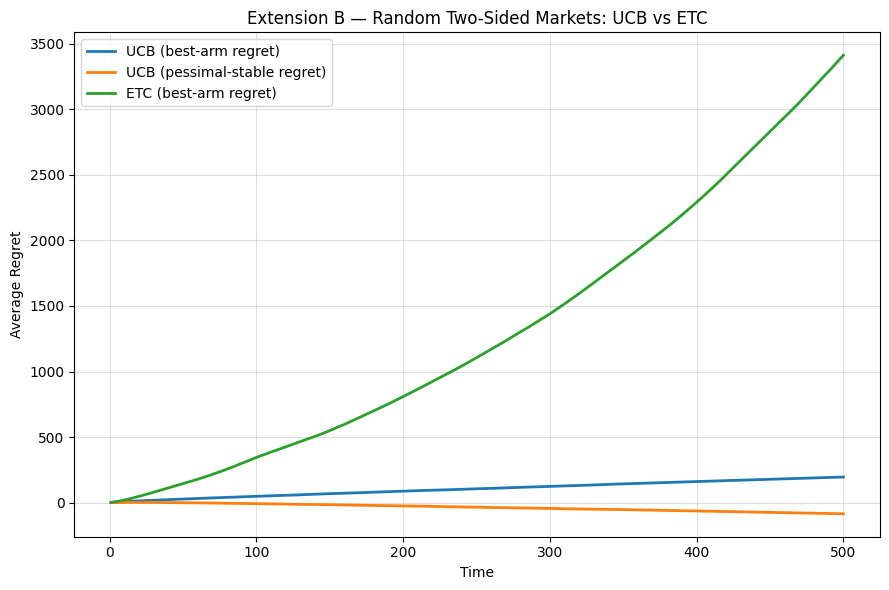

In [38]:
best_arm, pessimal, etc_reg = run_random_experiment_full()

T = best_arm.shape[1]
t = np.arange(1, T + 1)

plt.figure(figsize=(9, 6))
plt.plot(t, best_arm.mean(axis=0), label="UCB (best-arm regret)", linewidth=2)
plt.plot(t, pessimal.mean(axis=0), label="UCB (pessimal-stable regret)", linewidth=2)
plt.plot(t, etc_reg.mean(axis=0), label="ETC (best-arm regret)", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Average Regret")
plt.title("Extension B — Random Two-Sided Markets: UCB vs ETC")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#### **Discussion (B2)**

##### **UCB best-arm regret**
- Typically grows **linearly**, often with a steep slope.  
- There is significant **variability across agents**: some consistently win desirable arms, while others repeatedly lose conflicts and accumulate high regret.  
- This indicates that UCB cannot reliably secure high-value arms for all agents in random two-sided markets.

##### **UCB pessimal-stable regret**
- Generally lower than best-arm regret because the baseline is easier to beat.  
- Sometimes becomes **negative**, meaning UCB occasionally outperforms each agent’s *worst* stable partner.  
- However, regret often continues to grow, demonstrating that UCB frequently violates even the lower bound imposed by the pessimal stable matching.

##### **ETC best-arm regret**
- ETC performs the **worst** in random markets.  
- After its short exploration phase, ETC commits permanently to a single matching, which is almost always suboptimal in these irregular environments.  
- This leads to **steep, linear regret** and fragile performance compared to UCB.

**Take-away:**  
Random two-sided markets expose major weaknesses in both algorithms—UCB adapts but is unstable, and ETC is extremely brittle once committed.  
The rich structure of random preferences generates persistent conflicts that neither algorithm successfully resolves.

### **3.2.3 B3 — Best-Arm vs Pessimal-Stable Regret Visualization**

To better understand UCB’s behavior in random markets, we visualize regret using two baselines:

#### **1. Best-Arm Regret (left subplot)**  
- Faint individual curves highlight high agent-to-agent variability.  
- A thick mean curve shows overall behavior.  
- Shaded areas illustrate standard deviation.  
- Demonstrates how difficult it is for UCB to consistently allocate the best arm to each agent.

#### **2. Pessimal-Stable Regret (right subplot)**  
- Baseline is each agent’s pessimally stable partner.  
- Curves are lower and sometimes negative, showing UCB occasionally performs *better* than this worst-case stable outcome.  
- Still exhibits increasing regret in many trials, indicating instability relative to stable matchings.

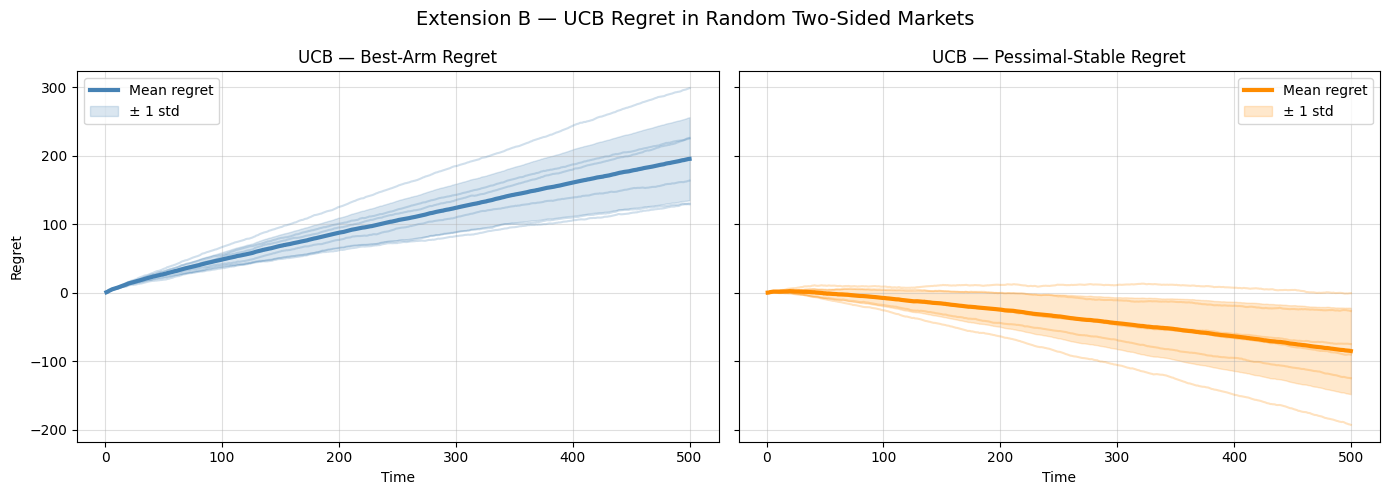

In [39]:
# Summary statistics across agents
best_mean = best_arm.mean(axis=0)
best_std = best_arm.std(axis=0)

pess_mean = pessimal.mean(axis=0)
pess_std = pessimal.std(axis=0)

t = np.arange(1, best_arm.shape[1] + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Best-arm regret (UCB)
axs[0].set_title("UCB — Best-Arm Regret")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Regret")

for i in range(best_arm.shape[0]):
    axs[0].plot(t, best_arm[i], color="steelblue", alpha=0.25)

axs[0].plot(t, best_mean, color="steelblue", linewidth=3, label="Mean regret")
axs[0].fill_between(
    t,
    best_mean - best_std,
    best_mean + best_std,
    color="steelblue",
    alpha=0.2,
    label="± 1 std"
)
axs[0].grid(True, alpha=0.4)
axs[0].legend()

# Pessimal-stable regret (UCB)
axs[1].set_title("UCB — Pessimal-Stable Regret")
axs[1].set_xlabel("Time")

for i in range(pessimal.shape[0]):
    axs[1].plot(t, pessimal[i], color="darkorange", alpha=0.25)

axs[1].plot(t, pess_mean, color="darkorange", linewidth=3, label="Mean regret")
axs[1].fill_between(
    t,
    pess_mean - pess_std,
    pess_mean + pess_std,
    color="darkorange",
    alpha=0.2,
    label="± 1 std"
)
axs[1].grid(True, alpha=0.4)
axs[1].legend()

plt.suptitle("Extension B — UCB Regret in Random Two-Sided Markets", fontsize=14)
plt.tight_layout()
plt.show()

#### **Discussion (B3)**

**Key observations**

- Regret grows **roughly linearly** under both baselines.
- **Best-arm regret** is consistently higher because the best arm is often inaccessible due to arm preferences.
- **Pessimal-stable regret** is more forgiving and captures when UCB exceeds or falls behind the worst stable partner.
- Large variability across agents arises from structural randomness in preferences, not from noise in learning.


### **3.2.4 Overall Conclusions for Extension B**

Random two-sided markets provide a strong stress test for bandit algorithms.
Our findings show that:

* **UCB adapts**, but does not reliably converge in unstructured environments.
* **ETC is brittle** and performs very poorly after committing based on limited early information.
* **Best-arm regret** illustrates persistent conflicts that prevent agents from reaching their optimal outcomes.
* **Pessimal-stable regret** highlights how UCB misaligns with stable matching structure, even in conservative comparisons.
* **Large agent variability** is inherent to random markets, revealing challenges hidden in structured examples.

Overall, these experiments indicate that simple bandit algorithms (UCB, ETC) are **not robust** in generic matching markets and motivate more specialized learning mechanisms.

## **3.3 Extension C — Two-Sided ETC**

Up to this point, all uncertainty existed only **on the agents’ side**:  
agents received noisy rewards when matched to arms, while arms had **fixed and known** preferences.  
This is exactly the setting of the paper *Competing Bandits in Matching Markets*.

In many real-world markets, however, **both sides learn**:

- agents do not know their true utilities over arms,
- arms do not know their true utilities over agents,
- both must infer preferences from noisy interactions.

Examples: job markets (firms and applicants), college matching (schools and students), online platforms (buyers and sellers).

To model this, we introduce a **Two-Sided Explore–Then–Commit (Two-Sided ETC)** algorithm, in which  
**both agents and arms estimate their preferences during exploration**, and then the platform commits to a stable matching based on these learned preferences.

### **3.3.1 C1 — Two-Sided ETC: Algorithm**

Two-Sided ETC has two phases:

1. **Exploration phase:** both sides estimate utilities.  
2. **Commit phase:** both sides form learned preferences and Gale–Shapley is run once.

<br>

#### **1. Exploration phase**

For the first $hK$ rounds, agents are assigned to arms in a **cyclic schedule**, so that each pair $(i,j)$ is visited multiple times.

When agent $i$ is matched to arm $j$ at time $t$:

- the **agent** observes
  $$
  X_{i,j}(t) \sim {N}(\mu_{i,j}, 1)
  $$
  and updates its estimate $\hat{\mu}_{i,j}$,

- the **arm** observes
  $$
  Y_{j,i}(t) \sim {N}(\gamma_{j,i}, 1)
  $$
  and updates its estimate $\hat{\gamma}_{j,i}$.

After exploration:

- each agent ranks arms by decreasing $\hat{\mu}_{i,j}$,
- each arm ranks agents by decreasing $\hat{\gamma}_{j,i}$.

This produces **learned preference lists on both sides**.

<br>

##### **Choosing the exploration horizon $h$ (two-sided generalization)**

In the one-sided setting, the paper suggests

$$
h
=
\left\lceil
\frac{4}{\Delta^2}
\log\left(1 + \frac{n \Delta^2 N}{4}\right)
\right\rceil,
$$

where $\Delta$ is the smallest relevant mean-gap for agents, $N$ is the number of agents, and $n$ the time horizon.

For the **two-sided** case we generalize this idea:

1. Compute the true stable matching $m^*$ using **both** $\mu$ (agents) and $\gamma$ (arms).
2. Define the minimal **agent-side** gap
   $$
   \Delta_{\text{agents}}
   =
   \min_{i, j : \mu_{i,m^{*}(i)} > \mu_{i,j}}
   \bigl(\mu_{i,m^{*}(i)} - \mu_{i,j}\bigr),
   $$
3. Define the minimal **arm-side** gap
   $$
   \Delta_{\text{arms}}
   =
   \min_{j, i : \gamma_{j,n^{*}(j)} > \gamma_{j,i}}
   \bigl(\gamma_{j,n^{*}(j)} - \gamma_{j,i}\bigr),
   $$
   where $n^{*}(j)$ is the true stable partner of arm $j$.

4. Compute:
   $$
   h_{\text{agents}} =
   \left\lceil
   \frac{4}{\Delta_{\text{agents}}^{2}}
   \log\left(1 + \frac{n \Delta_{\text{agents}}^{2} N}{4}\right)
   \right\rceil,
   $$
   $$
   h_{\text{arms}} =
   \left\lceil
   \frac{4}{\Delta_{\text{arms}}^{2}}
   \log\left(1 + \frac{n \Delta_{\text{arms}}^{2} K}{4}\right)
   \right\rceil,
   $$
   and finally
   $$
   h = \max\{ h_{\text{agents}}, h_{\text{arms}} \}.
   $$

This is the **two-sided theoretical exploration length** we use in our implementation.

<br>

#### **2. Commit phase**

Once exploration ends:

1. Agents build learned preferences by sorting arms by $\hat{\mu}_{i,j}$.
2. Arms build learned preferences by sorting agents by $\hat{\gamma}_{j,i}$.
3. The platform runs **agent-proposing Gale–Shapley** on these learned preferences.
4. The resulting stable matching is played for all remaining rounds.

After this commit, **no further learning takes place**.

<br>

##### **Why Two-Sided ETC is interesting**

Two-Sided ETC lets us explore phenomena not present in the one-sided setting:

- **Two-sided noise:** both sides may learn incorrect rankings.
- **Frozen mistakes:** a single noisy commit can lock in bad matchings.
- **Sensitivity to $h$:** too small → bad rankings; too large → horizon spent on exploration.
- **Realism:** many real markets involve mutual evaluation (firms and workers, schools and students, etc.).

Overall, this extension shows how naive two-sided generalizations of ETC can become **very fragile**.

In [40]:
def compute_theoretical_h_two_sided(mu_players: np.ndarray, gamma_arms: np.ndarray, n_rounds: int) -> int:
    """
    Two-sided theoretical exploration horizon h via min gaps on both sides.
    """
    N, K = mu_players.shape

    player_rankings_true = [list(np.argsort(-mu_players[i])) for i in range(N)]
    arm_rankings_true = [list(np.argsort(-gamma_arms[j])) for j in range(K)]

    m_opt = gale_shapley_agent_proposing(player_rankings_true, arm_rankings_true)
    m_opt = np.array(m_opt)

    # Agent-side gap Δ_agents
    Delta_agents = np.inf
    for i in range(N):
        best_arm = m_opt[i]
        best_mean = mu_players[i, best_arm]
        for j in range(K):
            if mu_players[i, j] < best_mean:
                Delta_agents = min(Delta_agents, best_mean - mu_players[i, j])

    # Arm-side gap Δ_arms
    Delta_arms = np.inf
    for j in range(K):
        matched_agents = np.where(m_opt == j)[0]
        if len(matched_agents) == 0:
            continue
        p = matched_agents[0]
        best_val = gamma_arms[j, p]
        for q in range(N):
            if gamma_arms[j, q] < best_val:
                Delta_arms = min(Delta_arms, best_val - gamma_arms[j, q])

    Delta_agents = max(1e-8, Delta_agents)
    Delta_arms = max(1e-8, Delta_arms)

    h_agents = int(np.ceil((4.0 / Delta_agents**2) * np.log(1.0 + (n_rounds * Delta_agents**2 * N) / 4.0)))
    h_arms = int(np.ceil((4.0 / Delta_arms**2) * np.log(1.0 + (n_rounds * Delta_arms**2 * K) / 4.0)))

    return max(1, h_agents, h_arms)

In [41]:
def etc_two_sided(mu_players: np.ndarray, gamma_arms: np.ndarray, n_rounds: int = 400, h: Optional[int] = None, rng: Optional[np.random.Generator] = None):
    """
    Two-sided ETC with theoretical h (if not provided).
    Returns matchings, agent rewards, arm rewards, and empirical means.
    """
    if rng is None:
        rng = np.random.default_rng()

    N, K = mu_players.shape

    if h is None:
        h = compute_theoretical_h_two_sided(mu_players, gamma_arms, n_rounds)
        print(f"[Two-Sided ETC] Theoretical h = {h}")

    matchings = np.full((n_rounds, N), -1, dtype=int)
    rewards_agents = np.zeros((n_rounds, N))
    rewards_arms = np.zeros((n_rounds, K))

    count = np.zeros((N, K))
    emp_mu_agents = np.zeros((N, K))
    emp_mu_arms = np.zeros((K, N))

    t = 0

    # Exploration
    for _ in range(h):
        for shift in range(K):
            if t >= n_rounds:
                break

            assign = [(i + shift) % K for i in range(N)]
            matchings[t] = assign

            for i in range(N):
                j = assign[i]

                r_agent = rng.normal(mu_players[i, j], 1.0)
                r_arm = rng.normal(gamma_arms[j, i], 1.0)

                rewards_agents[t, i] = r_agent
                rewards_arms[t, j] = r_arm

                count[i, j] += 1
                emp_mu_agents[i, j] += (r_agent - emp_mu_agents[i, j]) / count[i, j]
                emp_mu_arms[j, i] += (r_arm - emp_mu_arms[j, i]) / count[i, j]

            t += 1
        if t >= n_rounds:
            break

    # Commit
    player_rankings = [list(np.argsort(-emp_mu_agents[i])) for i in range(N)]
    arm_rankings = [list(np.argsort(-emp_mu_arms[j])) for j in range(K)]
    matches_commit = gale_shapley_agent_proposing(player_rankings, arm_rankings)

    while t < n_rounds:
        matchings[t] = matches_commit
        for i in range(N):
            j = matches_commit[i]
            rewards_agents[t, i] = rng.normal(mu_players[i, j], 1.0)
            rewards_arms[t, j] = rng.normal(gamma_arms[j, i], 1.0)
        t += 1

    return matchings, rewards_agents, rewards_arms, emp_mu_agents, emp_mu_arms

**Example**

[Two-Sided ETC] Theoretical h = 3044


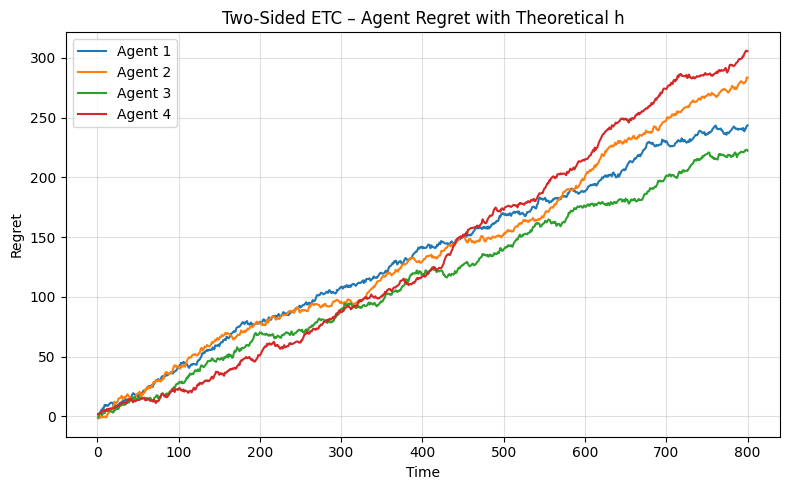

In [42]:
rng = np.random.default_rng(1)

N = 4
K = 4
n_rounds = 800

mu_players = rng.uniform(0, 1, size=(N, K))
gamma_arms = rng.uniform(0, 1, size=(K, N))

matchings, rew_agents, rew_arms, est_mu_agents, est_mu_arms = etc_two_sided(
    mu_players, gamma_arms,
    n_rounds=n_rounds,
    h=None,
    rng=rng
)

optimal_arm_for = np.argmax(mu_players, axis=1)
best_means = mu_players[np.arange(N), optimal_arm_for]

t = np.arange(1, n_rounds + 1)
optimal_reward_trace = best_means[:, None] * t[None, :]
obtained_reward_trace = np.cumsum(rew_agents, axis=0).T
regret_agents = optimal_reward_trace - obtained_reward_trace

plt.figure(figsize=(8, 5))
for i in range(N):
    plt.plot(t, regret_agents[i], label=f'Agent {i+1}')
plt.xlabel('Time')
plt.ylabel('Regret')
plt.title('Two-Sided ETC – Agent Regret with Theoretical h')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#### **Discussion (C1) — Behavior of Two-Sided ETC with Theoretical $h$**

**1. Theoretical $h$ is huge**

Using the two-sided formula, we obtain a theoretical
$$ h = \max{ h_{\text{agents}}, h_{\text{arms}} } $$
that can easily exceed the entire horizon (for example $h = 3044$ when $n = 800$).

Reason:

* both $\mu$ and $\gamma$ often contain very small gaps $\Delta$,
* the bound scales like $4 / \Delta^2$,
* so even tiny gaps blow up the required exploration length.

In our example, since $h > n$, the algorithm **never reaches the commit phase** and stays in pure exploration.

**2. Linear regret is expected**

If the entire horizon is spent exploring:

* agents rotate over arms,
* arms never settle on stable partners,
* there is no exploitation of learned information.

Each agent repeatedly pulls suboptimal arms, so regret grows by a roughly constant amount per round → **almost perfectly linear regret**.

**3. Two-sided learning amplifies instability**

In the one-sided ETC:

* only agents learn,
* arms’ preferences are fixed and known,
* with a properly chosen $h$, the algorithm can eventually recover the correct stable matching.

In the two-sided setting:

* both sides learn under noise,
* both sets of rankings can be wrong,
* Gale–Shapley is run on **noisy** preferences.

Even if $h$ were small enough to allow a commit phase, early noise on either side can distort the final matching.

**Take-away**

> Two-Sided ETC with theoretical $h$ is **not practical**:
> $h$ is often larger than the time horizon, the algorithm stays in exploration, and regret is linear.

### **3.3.2 C2 — Two-Sided ETC vs One-Sided ETC**

We now compare:

* **One-sided ETC** (as in the paper): only agents learn, arms have fixed preferences.
* **Two-sided ETC**: both agents and arms learn their preferences.

[Two-Sided ETC] Theoretical h = 1824


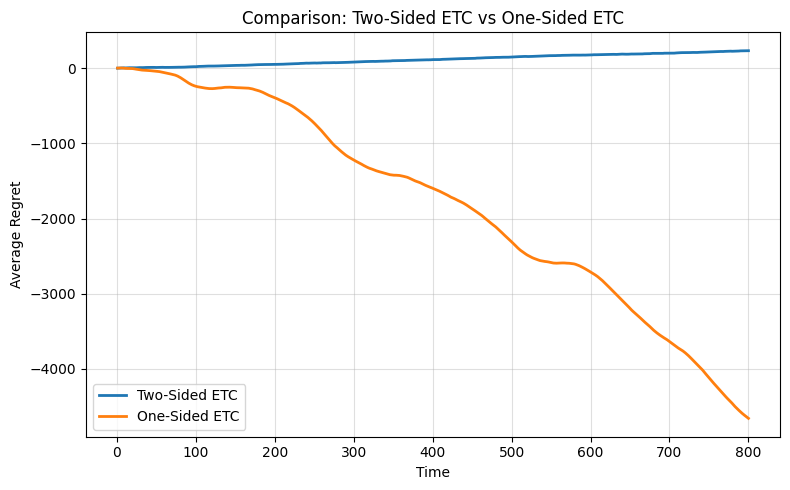

In [43]:
rng = np.random.default_rng(3)

mu_players = rng.uniform(0, 1, size=(N, K))
gamma_arms = rng.uniform(0, 1, size=(K, N))

match_t2, rew_t2, _, _, _ = etc_two_sided(mu_players, gamma_arms, n_rounds=n_rounds, h=None, rng=rng)

arm_pref_fixed = [list(np.argsort(-gamma_arms[j])) for j in range(K)]
player_fixed_rankings = [list(np.argsort(-mu_players[i])) for i in range(N)]
Delta, h_one = compute_min_gap_and_h(mu_players, arm_pref_fixed, n_rounds)

match_t1, rew_t1, _, _ = centralized_etc(mu_players, arm_pref_fixed, n_rounds=n_rounds, h=h_one, rng=rng)

best_for = np.argmax(mu_players, axis=1)
best_means = mu_players[np.arange(N), best_for]
t = np.arange(1, n_rounds + 1)

opt_trace = best_means[:, None] * t[None, :]
reg_t2 = opt_trace - np.cumsum(rew_t2, axis=0).T
reg_t1 = opt_trace - np.cumsum(rew_t1, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(t, reg_t2.mean(axis=0), label="Two-Sided ETC", linewidth=2)
plt.plot(t, reg_t1.mean(axis=0), label="One-Sided ETC", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Average Regret")
plt.title("Comparison: Two-Sided ETC vs One-Sided ETC")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#### **Discussion — Two-Sided ETC vs One-Sided ETC**

**1. One-sided ETC behaves as expected**

In the one-sided case:

* only $\mu$ is unknown, arms’ preferences are known,
* theoretical $h$ is moderate,
* after exploration, learned rankings are mostly correct.

Result: one-sided ETC

* quickly finds a good stable matching,
* commits to it,
* and shows **slowly increasing regret**.

**2. Two-sided ETC performs much worse**

In the two-sided case:

* agents estimate $\mu_{i,j}$,
* arms estimate $\gamma_{j,i}$,
* both sets of rankings are noisy.

If early samples are unlucky:

* agents mis-rank arms,
* arms mis-rank agents,
* the final Gale–Shapley matching can be far from the true stable one.

After the commit, these errors are **frozen**, so regret grows much faster than in the one-sided case.

**3. Theoretical $h$ is unrealistic**

The two-sided formula for $h$ is dominated by the smallest gaps on both sides:

* small $\Delta_{\text{agents}}$ or $\Delta_{\text{arms}}$ → huge $h$,
* in practice $h$ often exceeds $n$.

Thus, there is no reasonable choice of $h$ that is both:

* statistically “safe” (in the theoretical sense),
* and computationally practical.

**Take-away**

> Adding learning on the arms’ side dramatically worsens ETC’s behavior:
> even though the algorithmic structure looks the same, two-sided noise makes explore–then–commit highly fragile.

### **3.3.3 C3 — Two-Sided ETC vs Centralized UCB**

We finally compare Two-Sided ETC with **Centralized UCB** on the same instance.

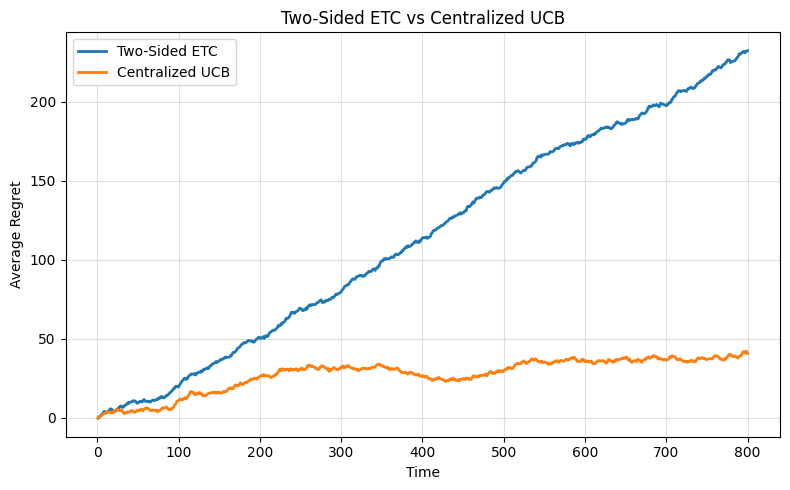

In [44]:
rng = np.random.default_rng(4)

_, _, _, rew_ucb = centralized_ucb(mu_players, arm_pref_fixed, n_rounds=n_rounds, rng=rng)
reg_ucb = opt_trace - np.cumsum(rew_ucb, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(t, reg_t2.mean(axis=0), label="Two-Sided ETC", linewidth=2)
plt.plot(t, reg_ucb.mean(axis=0), label="Centralized UCB", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Average Regret")
plt.title("Two-Sided ETC vs Centralized UCB")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#### **Discussion — Two-Sided ETC vs Centralized UCB**

**1. Centralized UCB keeps learning**

Centralized UCB:

* updates estimates at every round,
* never fully commits to a fixed matching,
* continuously corrects earlier mistakes.

As time goes on, UCB:

* learns which agent–arm pairs work well,
* gradually reduces the frequency of bad matches,
* and often exhibits **sublinear** or slower-growing regret compared to ETC.

**2. Two-Sided ETC is rigid**

Two-Sided ETC:

1. explores for $hK$ rounds,
2. commits once,
3. never updates again.

Any noise in that exploration window directly affects:

* agents’ learned rankings,
* arms’ learned rankings,
* and the final stable matching.

Once set, the matching does not change, so regret grows steadily.

**3. Why UCB outperforms Two-Sided ETC**

The key difference:

* **UCB can correct its mistakes**,
* **ETC cannot** once the commit happens.

So even if UCB starts off worse, it has the chance to recover; Two-Sided ETC does not.

**Take-away**

> In two-sided learning environments, continuous-learning algorithms like UCB
> are far more robust than single-commit schemes like ETC.

### **3.3.4 C4 — Effect of the Exploration Length $h$ in Two-Sided ETC**

We now study how changing $h$ affects Two-Sided ETC, comparing:

* **Small $h$ (under-exploration):** $h = 2$
* **Moderate $h$:** $h = 10$
* **Theoretical $h$ (very large):** value computed from the two-sided formula

We evaluate **best-arm regret**, focusing on learning quality rather than stable baselines.

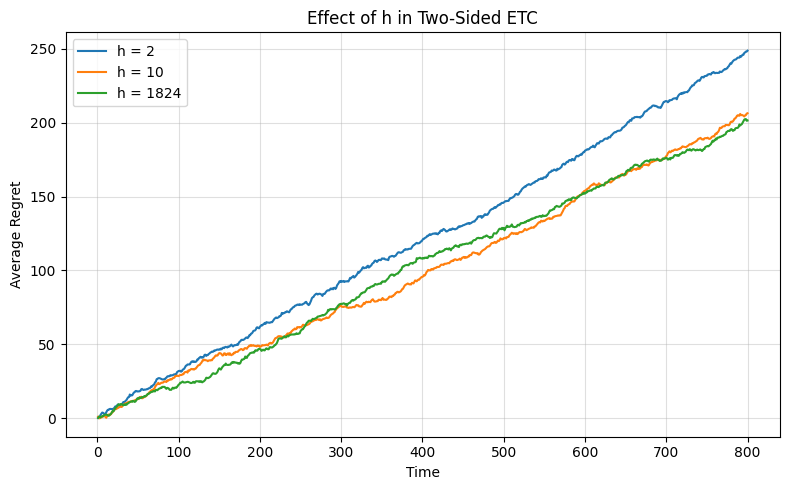

In [45]:
rng = np.random.default_rng(5)

h_small = 2
h_med = 10
h_big = compute_theoretical_h_two_sided(mu_players, gamma_arms, n_rounds)

_, r_small, _, _, _ = etc_two_sided(mu_players, gamma_arms, n_rounds, h=h_small, rng=rng)
_, r_med, _, _, _ = etc_two_sided(mu_players, gamma_arms, n_rounds, h=h_med, rng=rng)
_, r_big, _, _, _ = etc_two_sided(mu_players, gamma_arms, n_rounds, h=h_big, rng=rng)

reg_small = opt_trace - np.cumsum(r_small, axis=0).T
reg_med = opt_trace - np.cumsum(r_med, axis=0).T
reg_big = opt_trace - np.cumsum(r_big, axis=0).T

plt.figure(figsize=(8, 5))
plt.plot(t, reg_small.mean(axis=0), label="h = 2")
plt.plot(t, reg_med.mean(axis=0), label="h = 10")
plt.plot(t, reg_big.mean(axis=0), label=f"h = {h_big}")
plt.xlabel("Time")
plt.ylabel("Average Regret")
plt.title("Effect of h in Two-Sided ETC")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#### **Discussion — Effect of $h$**

**1. Very small $h$ (under-exploration)**

* each pair $(i,j)$ is sampled only a few times,
* estimates $\hat{\mu}*{i,j}$ and $\hat{\gamma}*{j,i}$ are very noisy,
* learned preferences are unreliable.

Result: ETC commits to a bad matching and regret grows **quickly and almost linearly**.

**2. Moderate $h$ (still too small)**

With $h = 10$:

* there is more information,
* regret improves compared to $h = 2$,
* but estimates on both sides are still far from accurate.

The algorithm still commits to a mismatched outcome, and regret continues to grow at a significant rate.

**3. Theoretical $h$ (statistically safe but impractical)**

With the huge theoretical $h$:

* the algorithm spends most (or all) of the horizon exploring,
* almost no time is left for exploitation,
* regret is dominated by poor exploration outcomes.

This makes the theoretical choice of $h$ **useless in practice**.

**Take-away**

Two-Sided ETC is extremely sensitive to the choice of $h$:

* if $h$ is too small → inaccurate learned preferences → bad commit,
* if $h$ is large enough to be theoretically sound → horizon is consumed by exploration.

> There is effectively **no practical $h$** that makes Two-Sided ETC both statistically reliable and efficient in two-sided markets.

This underlines a broader lesson of Extension C:

* explore–then–commit is fundamentally ill-suited to two-sided learning,
* continuous-learning schemes (like centralized UCB) are better suited when **both sides** must learn their preferences.